# Multiplex Model Interpretability

Three main lenses:
1. **Cross-attention weights** — which time steps each label query attends to, and how labels attend to each other.
2. **GradCAM / saliency** — which parts of the curve drive the most confident prediction for each 3-bit target combination.
3. **Additional** — embedding space (UMAP), CRF state probability heatmap, per-label calibration.

> Works with any `--cross_attn_v2` or `--crf` (CAttn+CRF) model.  
> Set `MODEL_KEY` and `MODEL_PATH` in the **Config** cell.

In [37]:
# ── Config ───────────────────────────────────────────────────────────────────
import os, glob

EXP_FOLDER  = '/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex'
EXP_PATH    = os.path.join(EXP_FOLDER, '01_ACA_qdPCR')

# cnn_gru_dual_cross_attn_v2_crf_flat covers 4/7 states correctly (most of any saved model)
MODEL_KEY   = 'cnn_gru_dual_cross_attn_v2_crf_flat'
IS_CRF      = 'crf' in MODEL_KEY

_hits = glob.glob(os.path.join(EXP_PATH, 'models', f'{MODEL_KEY}_None_*.keras'))
assert _hits, f"No saved model found for {MODEL_KEY} in {EXP_PATH}/models/"
MODEL_PATH  = _hits[0]
print("Model file:", os.path.basename(MODEL_PATH))

TARGETS      = ['KPC', 'NDM', 'VIM']
N_TARGETS    = len(TARGETS)
N_STATES     = 2 ** N_TARGETS
STATE_LABELS = [
    '|'.join(f'{t}+' if (s >> j) & 1 else f'{t}-' for j, t in enumerate(TARGETS))
    for s in range(N_STATES)
]
print('States:', STATE_LABELS)


Model file: cnn_gru_dual_cross_attn_v2_crf_flat_None_CRF SC0.keras
States: ['KPC-|NDM-|VIM-', 'KPC+|NDM-|VIM-', 'KPC-|NDM+|VIM-', 'KPC+|NDM+|VIM-', 'KPC-|NDM-|VIM+', 'KPC+|NDM-|VIM+', 'KPC-|NDM+|VIM+', 'KPC+|NDM+|VIM+']


In [38]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import joblib
import tensorflow as tf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

sys.path.insert(0, '/vol/bitbucket/gk225/POC_DDM/gk_code')
sys.path.insert(0, '/vol/bitbucket/gk225/POC_DDM/gk_code/main/multiplex')
sys.path.insert(0, '/vol/bitbucket/gk225/POC_DDM/gk_code/main/multiplex/utils/model_training')

from model_utils_multilabel import (
    LabelQueryEmbedding,
    CRFFactoredHead, CRFBilinearHead,
    MultiLabelCRFMRFModel,  MultiLabelCRFMRFSC1Model,
    MultiLabelCRFMRFSC2Model, MultiLabelCRFMRFSC3Model,
    MultiLabelCRFChainModel, MultiLabelCRFChainSC1Model,
    MultiLabelCRFChainSC2Model, MultiLabelCRFChainSC3Model,
)

CUSTOM_OBJECTS = {
    'LabelQueryEmbedding':        LabelQueryEmbedding,
    'CRFFactoredHead':            CRFFactoredHead,
    'CRFBilinearHead':            CRFBilinearHead,
    'MultiLabelCRFMRFModel':      MultiLabelCRFMRFModel,
    'MultiLabelCRFMRFSC1Model':   MultiLabelCRFMRFSC1Model,
    'MultiLabelCRFMRFSC2Model':   MultiLabelCRFMRFSC2Model,
    'MultiLabelCRFMRFSC3Model':   MultiLabelCRFMRFSC3Model,
    'MultiLabelCRFChainModel':    MultiLabelCRFChainModel,
    'MultiLabelCRFChainSC1Model': MultiLabelCRFChainSC1Model,
    'MultiLabelCRFChainSC2Model': MultiLabelCRFChainSC2Model,
    'MultiLabelCRFChainSC3Model': MultiLabelCRFChainSC3Model,
}

In [39]:
# ── Load training data ────────────────────────────────────────────────────────
data = joblib.load(os.path.join(EXP_PATH, 'curve_for_training_ml.joblib'))

# curves['ori_curves']: (N, T) — add channel dim for Keras
X_all = data['curves']['ori_curves'][:, :, None].astype(np.float32)  # (N, T, 1)
y_all = data['label_binarized'].astype(np.float32)                    # (N, 3)

# Encode each sample as a 3-bit state index (0-7)
decode_mat = np.array([[int((s >> j) & 1) for j in range(N_TARGETS)]
                        for s in range(N_STATES)], dtype=np.float32)  # (8, 3)
state_idx_all = np.array([
    np.where((decode_mat == row).all(axis=1))[0][0] for row in y_all
])

print(f'Dataset: {X_all.shape}  y: {y_all.shape}')
print('State distribution:', {STATE_LABELS[s]: int((state_idx_all == s).sum())
                               for s in range(N_STATES)})

Dataset: (26571, 45, 1)  y: (26571, 3)
State distribution: {'KPC-|NDM-|VIM-': 0, 'KPC+|NDM-|VIM-': 6792, 'KPC-|NDM+|VIM-': 6232, 'KPC+|NDM+|VIM-': 1638, 'KPC-|NDM-|VIM+': 7223, 'KPC+|NDM-|VIM+': 1582, 'KPC-|NDM+|VIM+': 1535, 'KPC+|NDM+|VIM+': 1569}


In [40]:
# ── Load model ────────────────────────────────────────────────────────────────
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=CUSTOM_OBJECTS)
print(f'Loaded: {MODEL_KEY}')

# Print layer names to help debug attention extraction
ca2_layers = [l.name for l in model.layers if 'ca2_' in l.name]
print('CA2 layers:', ca2_layers[:20])

Loaded: cnn_gru_dual_cross_attn_v2_crf_flat
CA2 layers: ['ca2_bigru1', 'ca2_gru_ln', 'ca2_bigru2', 'ca2_label_q_emb', 'ca2_kv_proj', 'ca2_cross_attn_0', 'ca2_ca_ln_0', 'ca2_inter_sa_0', 'ca2_sa_ln_0', 'ca2_ffn1_0', 'ca2_ffn2_0', 'ca2_ffn_ln_0', 'ca2_cross_attn_1', 'ca2_ca_ln_1', 'ca2_inter_sa_1', 'ca2_sa_ln_1', 'ca2_ffn1_1', 'ca2_ffn2_1', 'ca2_ffn_ln_1']


In [41]:
# ── Helper: get model logits (handles SC multi-output + batched inference) ───
def get_logits(model, x, batch_size=512):
    chunks = []
    for i in range(0, len(x), batch_size):
        out = model(x[i:i+batch_size], training=False)
        if isinstance(out, (list, tuple)): out = out[0]
        chunks.append(out.numpy())
    return np.concatenate(chunks, axis=0)

print('Output shape:', get_logits(model, X_all[:4]).shape)


Output shape: (4, 8)


---
## 1. Cross-Attention Weights

Two sub-plots per sample:
- **CA weights** `(n_heads, n_targets, T)` — which time steps each label query focuses on.
- **Inter-label SA weights** `(n_heads, n_targets, n_targets)` — how labels relate to each other after cross-attention.

Both CA blocks are visualised (block 0 = early, block 1 = refined).

In [42]:
# ── Build sub-models to extract Q and KV tensors ──────────────────────────────
def _layer_output_model(model, layer_name):
    return tf.keras.Model(inputs=model.inputs,
                          outputs=model.get_layer(layer_name).output)

# CA block 0 inputs: initial queries from LabelQueryEmbedding, projected KV seq
q_emb_model   = _layer_output_model(model, 'ca2_label_q_emb')
kv_proj_model = _layer_output_model(model, 'ca2_kv_proj')

# After CA block 0 cross-attn → input to inter-label SA 0
ca_ln_0_model  = _layer_output_model(model, 'ca2_ca_ln_0')
# After full block 0 (cross-attn + ISA + FFN) → input to CA block 1 cross-attn
ffn_ln_0_model = _layer_output_model(model, 'ca2_ffn_ln_0')
# After CA block 1 cross-attn → input to inter-label SA 1
ca_ln_1_model  = _layer_output_model(model, 'ca2_ca_ln_1')

# MHA layers (cross-attn and inter-label SA)
ca_mha_0  = model.get_layer('ca2_cross_attn_0')
ca_mha_1  = model.get_layer('ca2_cross_attn_1')
isa_mha_0 = model.get_layer('ca2_inter_sa_0')
isa_mha_1 = model.get_layer('ca2_inter_sa_1')

def get_attention_weights(x):
    """Returns dict of attention weight arrays for one batch."""
    x = tf.cast(x, tf.float32)

    q0 = q_emb_model(x, training=False)      # (B, n_targets, query_dim)
    kv = kv_proj_model(x, training=False)    # (B, T, query_dim)

    # Block 0
    _, ca0_w  = ca_mha_0(query=q0, value=kv, key=kv,
                          return_attention_scores=True, training=False)
    q1 = ca_ln_0_model(x, training=False)    # input to ISA 0
    _, isa0_w = isa_mha_0(q1, q1, return_attention_scores=True, training=False)

    # Block 1 — input is ffn_ln_0 (after full block 0, not just sa_ln_0)
    q2 = ffn_ln_0_model(x, training=False)
    _, ca1_w  = ca_mha_1(query=q2, value=kv, key=kv,
                          return_attention_scores=True, training=False)
    q3 = ca_ln_1_model(x, training=False)    # input to ISA 1
    _, isa1_w = isa_mha_1(q3, q3, return_attention_scores=True, training=False)

    return {
        'ca_0':  ca0_w.numpy(),    # (B, n_heads, n_targets, T)
        'isa_0': isa0_w.numpy(),   # (B, 2, n_targets, n_targets)
        'ca_1':  ca1_w.numpy(),
        'isa_1': isa1_w.numpy(),
    }


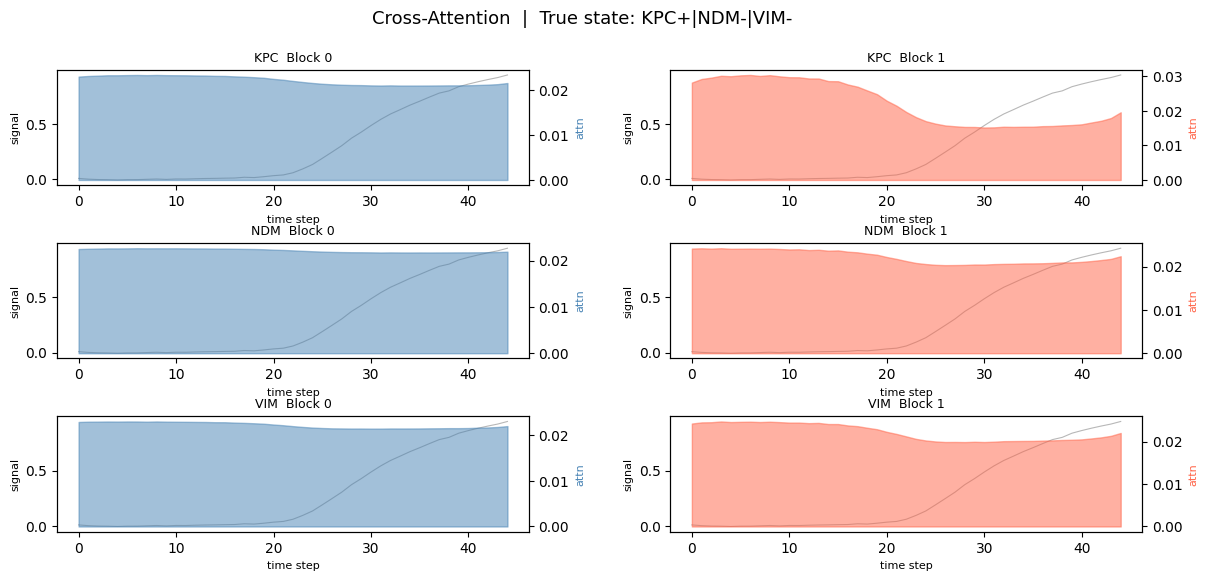

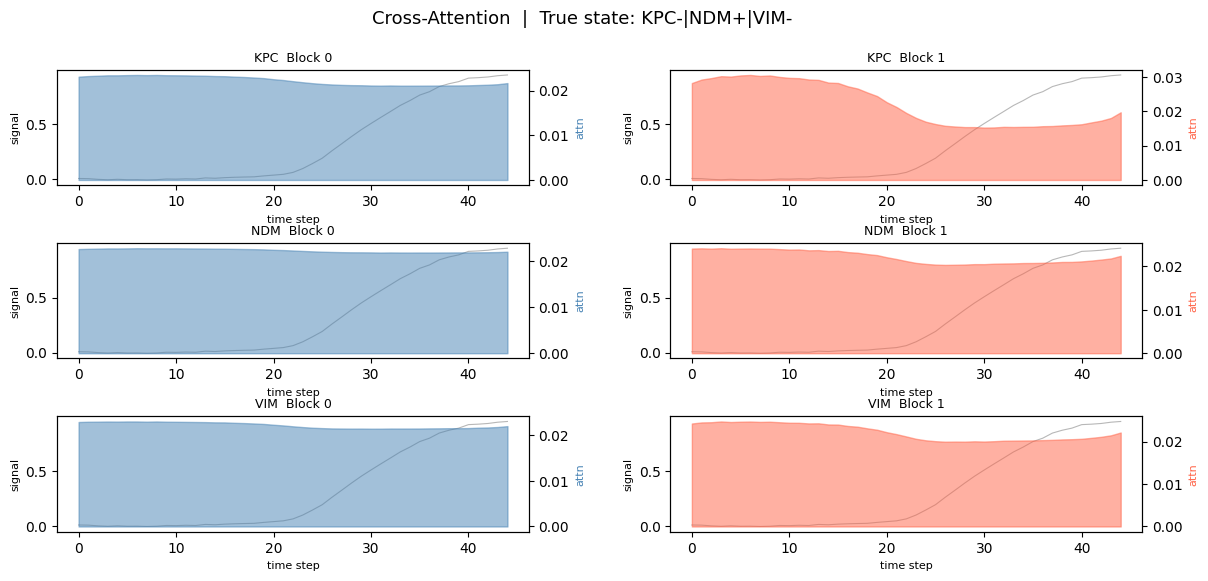

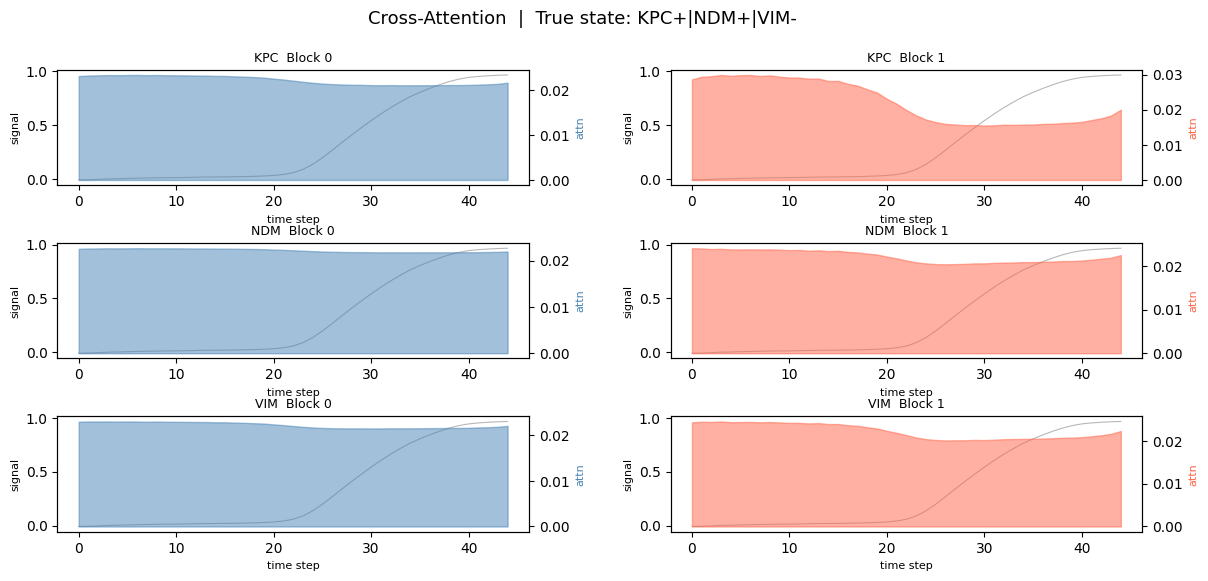

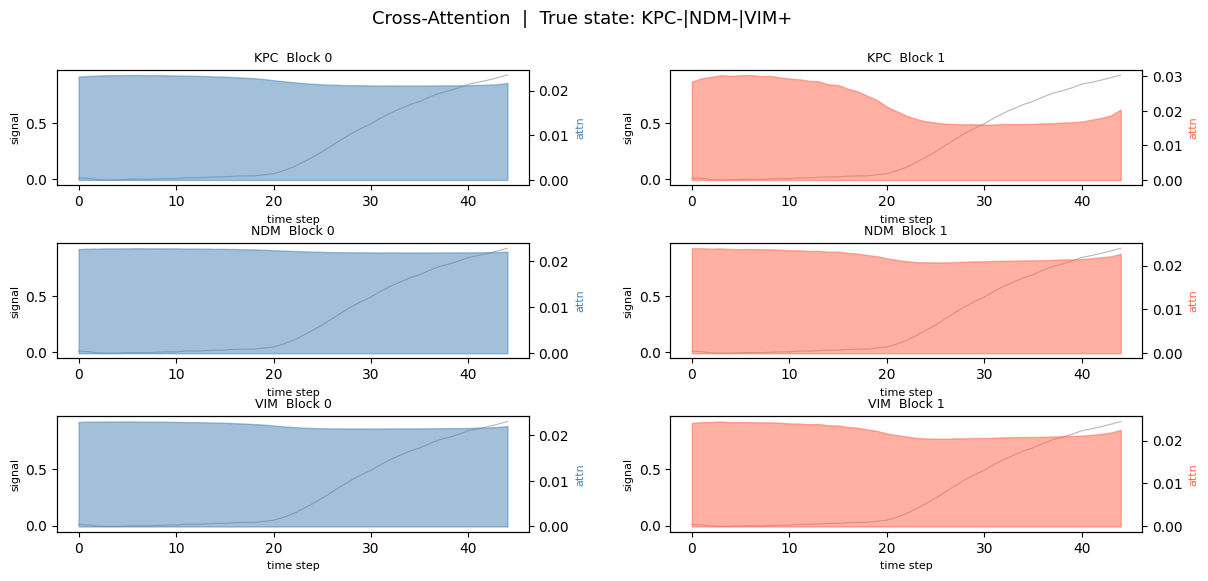

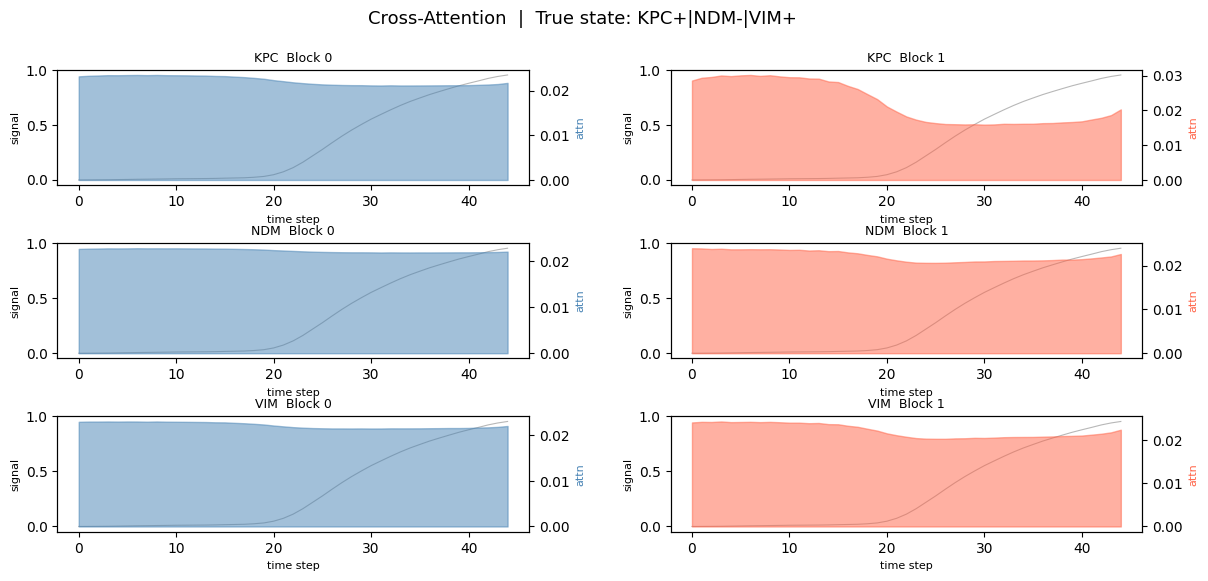

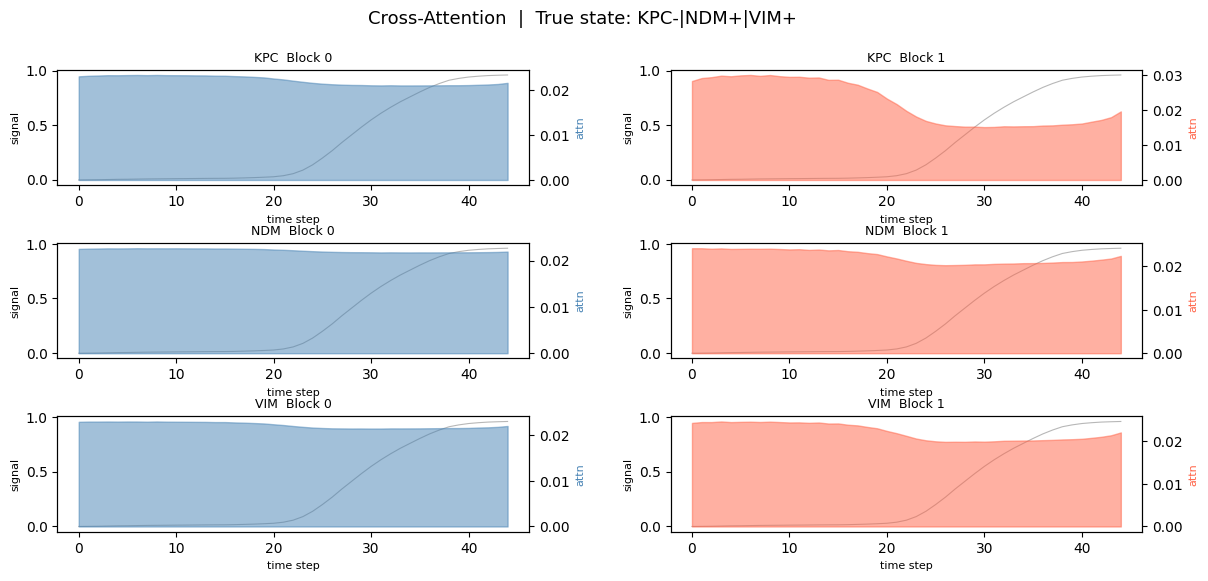

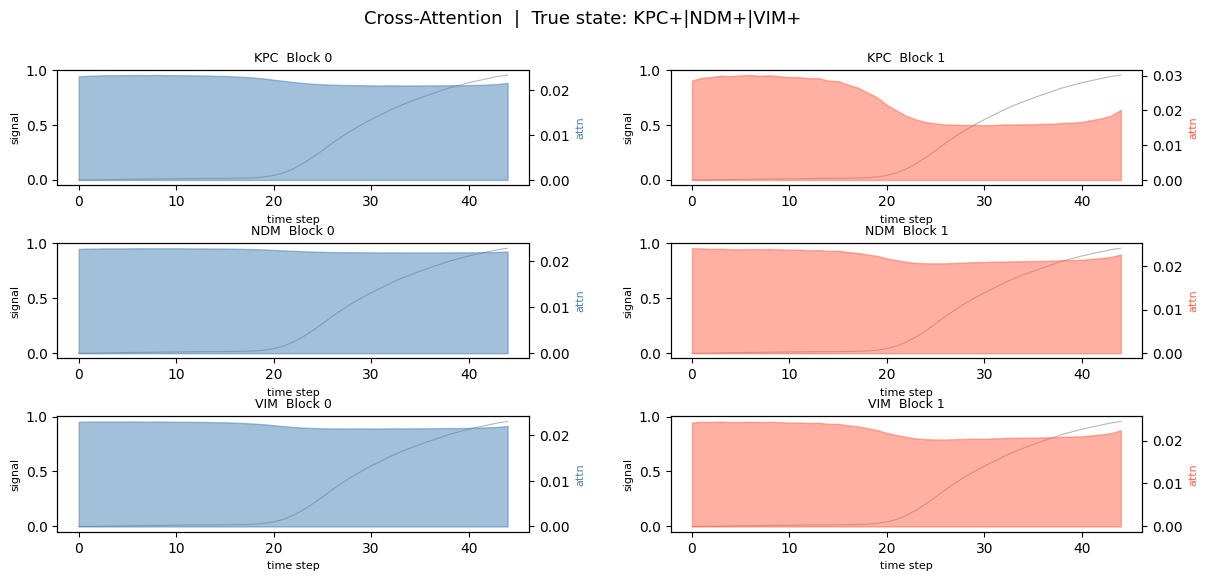

In [43]:
# ── Plot cross-attention for representative samples ───────────────────────────
def plot_cross_attention(x_samples, y_samples, state_indices, max_per_state=1):
    """One figure per state: raw curve + per-target attention heatmap for both CA blocks."""
    weights = get_attention_weights(x_samples)
    T = x_samples.shape[1]
    t = np.arange(T)

    # Avg over heads for clarity; shape (B, n_targets, T)
    ca0_avg = weights['ca_0'].mean(axis=1)
    ca1_avg = weights['ca_1'].mean(axis=1)

    for i in range(len(x_samples)):
        state = state_indices[i]
        fig, axes = plt.subplots(3, 2, figsize=(14, 6),
                                  gridspec_kw={'hspace': 0.5, 'wspace': 0.3})
        fig.suptitle(f'Cross-Attention  |  True state: {STATE_LABELS[state]}', fontsize=13)

        for j, target in enumerate(TARGETS):
            # CA block 0
            ax = axes[j, 0]
            ax2 = ax.twinx()
            ax.plot(t, x_samples[i, :, 0], color='#888', lw=0.8, alpha=0.6)
            ax2.fill_between(t, ca0_avg[i, j], alpha=0.5, color='steelblue')
            ax.set_title(f'{target}  Block 0', fontsize=9)
            ax.set_ylabel('signal', fontsize=8); ax2.set_ylabel('attn', fontsize=8, color='steelblue')
            ax.set_xlabel('time step', fontsize=8)

            # CA block 1
            ax = axes[j, 1]
            ax2 = ax.twinx()
            ax.plot(t, x_samples[i, :, 0], color='#888', lw=0.8, alpha=0.6)
            ax2.fill_between(t, ca1_avg[i, j], alpha=0.5, color='tomato')
            ax.set_title(f'{target}  Block 1', fontsize=9)
            ax.set_ylabel('signal', fontsize=8); ax2.set_ylabel('attn', fontsize=8, color='tomato')
            ax.set_xlabel('time step', fontsize=8)

        plt.show()


# Gather one sample per state
sample_x, sample_y, sample_s = [], [], []
for s in range(N_STATES):
    idx = np.where(state_idx_all == s)[0]
    if len(idx):
        sample_x.append(X_all[idx[0]])
        sample_y.append(y_all[idx[0]])
        sample_s.append(s)

sample_x = np.stack(sample_x)
sample_s = np.array(sample_s)

plot_cross_attention(sample_x, sample_y, sample_s)

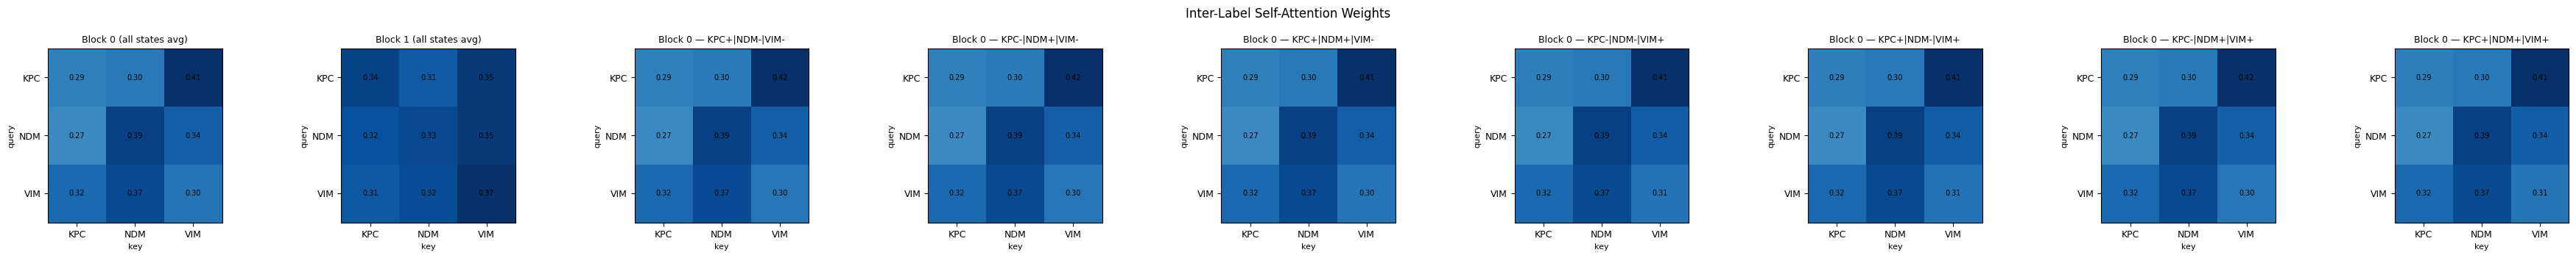

In [44]:
# ── Inter-label self-attention (label→label relation) ─────────────────────────
def plot_inter_label_sa(x_samples, state_indices):
    """Heatmap showing how each label attends to others after cross-attn."""
    weights = get_attention_weights(x_samples)

    # Average over all samples and both heads; shape (n_targets, n_targets)
    isa0_avg = weights['isa_0'].mean(axis=(0, 1))   # avg batch + heads
    isa1_avg = weights['isa_1'].mean(axis=(0, 1))

    # Also show per-state breakdown for ISA block 0
    state_present = np.unique(state_indices)

    fig, axes = plt.subplots(1, 2 + len(state_present),
                              figsize=(4 * (2 + len(state_present)), 3.5))
    fig.suptitle('Inter-Label Self-Attention Weights', fontsize=12)

    def _draw(ax, mat, title):
        im = ax.imshow(mat, vmin=0, vmax=mat.max(), cmap='Blues')
        ax.set_xticks(range(N_TARGETS)); ax.set_xticklabels(TARGETS, fontsize=9)
        ax.set_yticks(range(N_TARGETS)); ax.set_yticklabels(TARGETS, fontsize=9)
        ax.set_xlabel('key', fontsize=8); ax.set_ylabel('query', fontsize=8)
        ax.set_title(title, fontsize=9)
        for r in range(N_TARGETS):
            for c in range(N_TARGETS):
                ax.text(c, r, f'{mat[r,c]:.2f}', ha='center', va='center', fontsize=7)

    _draw(axes[0], isa0_avg, 'Block 0 (all states avg)')
    _draw(axes[1], isa1_avg, 'Block 1 (all states avg)')

    for k, s in enumerate(state_present):
        mask = state_indices == s
        per_state = weights['isa_0'][mask].mean(axis=(0, 1))
        _draw(axes[2 + k], per_state, f'Block 0 — {STATE_LABELS[s]}')

    plt.tight_layout()
    plt.show()

plot_inter_label_sa(sample_x, sample_s)

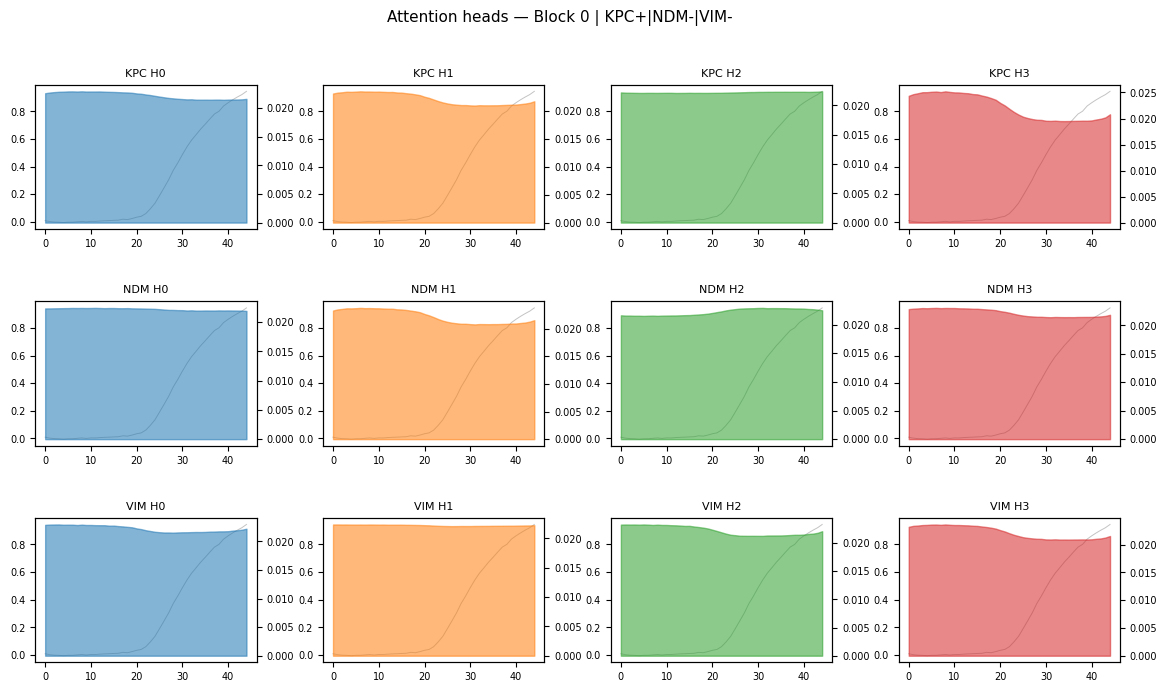

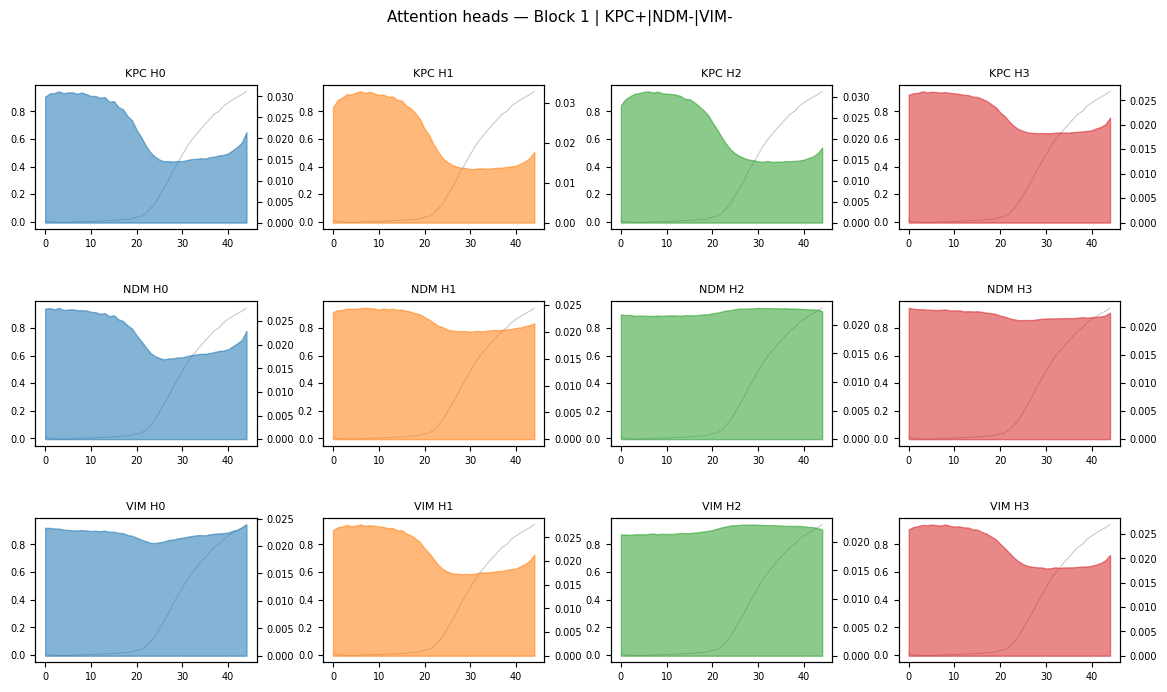

In [45]:
# ── All attention heads separately (diversity check) ─────────────────────────
def plot_attention_heads(x_single, state_label, block=0):
    """Show each attention head's focus for one sample."""
    weights = get_attention_weights(x_single[None])
    key = f'ca_{block}'
    attn = weights[key][0]   # (n_heads, n_targets, T)
    n_heads = attn.shape[0]
    T = x_single.shape[0]
    t = np.arange(T)

    fig, axes = plt.subplots(N_TARGETS, n_heads, figsize=(3.5 * n_heads, 2.5 * N_TARGETS),
                              gridspec_kw={'hspace': 0.5, 'wspace': 0.3})
    fig.suptitle(f'Attention heads — Block {block} | {state_label}', fontsize=11)

    for j, target in enumerate(TARGETS):
        for h in range(n_heads):
            ax = axes[j, h]
            ax2 = ax.twinx()
            ax.plot(t, x_single[:, 0], color='#888', lw=0.7, alpha=0.5)
            ax2.fill_between(t, attn[h, j], alpha=0.55, color=plt.cm.tab10(h))
            ax.set_title(f'{target} H{h}', fontsize=8)
            ax.tick_params(labelsize=7); ax2.tick_params(labelsize=7)

    plt.show()

# Show for the first available sample
plot_attention_heads(sample_x[0], STATE_LABELS[sample_s[0]], block=0)
plot_attention_heads(sample_x[0], STATE_LABELS[sample_s[0]], block=1)

---
## 2. GradCAM / Input Saliency

For the **most confident** correctly-classified sample per 3-bit state:
- **Input saliency**: `|∂ score / ∂ input|` — direct gradient on the raw time series.
- **GradCAM on CNN feature map**: `relu(∂ score / ∂ conv_out) · conv_out` pooled to 1D — highlights which time-window features matter.

Score = CRF state logit (for CRF models) or sigmoid output (for standard models).

In [46]:
# ── Saliency via GradientTape ────────────────────────────────────────────────
def input_saliency(model, x, class_idx):
    """Absolute gradient of the target score w.r.t. the input."""
    x_var = tf.Variable(tf.cast(x, tf.float32))
    with tf.GradientTape() as tape:
        out = model(x_var, training=False)
        if isinstance(out, (list, tuple)): out = out[0]
        score = out[:, class_idx]
    grads = tape.gradient(score, x_var)    # (B, T, 1)
    return tf.abs(grads).numpy()           # (B, T, 1)


# ── GradCAM on the KV-projection layer ───────────────────────────────────────
# ca2_kv_proj outputs (B, T, 64) at FULL temporal resolution — no upsampling needed.
# GradCAM: relu( mean_channel( d(score)/d(kv_proj) * kv_proj_out ) )
KV_LAYER = 'ca2_kv_proj'

def gradcam_1d(model, x, class_idx):
    """Returns 1D GradCAM heatmap at input time resolution."""
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(KV_LAYER).output,
                 model.outputs[0] if isinstance(model.output, list) else model.output]
    )
    x_t = tf.cast(x, tf.float32)
    with tf.GradientTape() as tape:
        kv_out, preds = grad_model(x_t, training=False)
        tape.watch(kv_out)
        score = preds[:, class_idx]
    grads = tape.gradient(score, kv_out)    # (B, T, 64)
    # Weight feature maps by channel-pooled gradients
    cam = tf.reduce_mean(grads * kv_out, axis=-1)   # (B, T)
    cam = tf.nn.relu(cam).numpy()
    # Normalise each sample
    cam = cam / (cam.max(axis=1, keepdims=True) + 1e-8)
    return cam   # (B, T) in [0, 1]


In [47]:
# ── Find most-confident correct prediction per state ─────────────────────────
all_logits = get_logits(model, X_all)

if IS_CRF:
    all_probs   = tf.nn.softmax(all_logits).numpy()   # (N, 8)
    pred_state  = all_probs.argmax(axis=1)
    confidence  = all_probs.max(axis=1)
else:
    all_probs_sig = tf.sigmoid(all_logits).numpy()    # (N, 3)
    pred_binary   = (all_probs_sig >= 0.5).astype(int)
    pred_state    = np.array([
        np.where((decode_mat == row).all(axis=1))[0][0] for row in pred_binary
    ])
    confidence = all_probs_sig.max(axis=1)

correct_mask = pred_state == state_idx_all

best = {}
for s in range(N_STATES):
    mask = correct_mask & (state_idx_all == s)
    if mask.any():
        cands   = np.where(mask)[0]
        best[s] = cands[confidence[cands].argmax()]

print(f'States with a correct prediction: {len(best)}/{N_STATES}')
for s, idx in best.items():
    print(f'  {STATE_LABELS[s]:30s}  idx={idx}  conf={confidence[idx]:.3f}')


States with a correct prediction: 4/8
  KPC+|NDM-|VIM-                  idx=23978  conf=0.578
  KPC-|NDM+|VIM-                  idx=3979  conf=0.352
  KPC+|NDM+|VIM-                  idx=9164  conf=0.265
  KPC+|NDM-|VIM+                  idx=8487  conf=0.318


---
## 2a. State Confusion Matrix (2ⁿ × 2ⁿ)

Rows = true state, columns = predicted state. Left: raw counts; right: row-normalised (recall per true state).
The diagonal = correctly classified. Off-diagonal entries show which states the model confuses.

/tmp/ipykernel_1188818/2158163279.py:8: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm_counts / row_sums, 0.0)


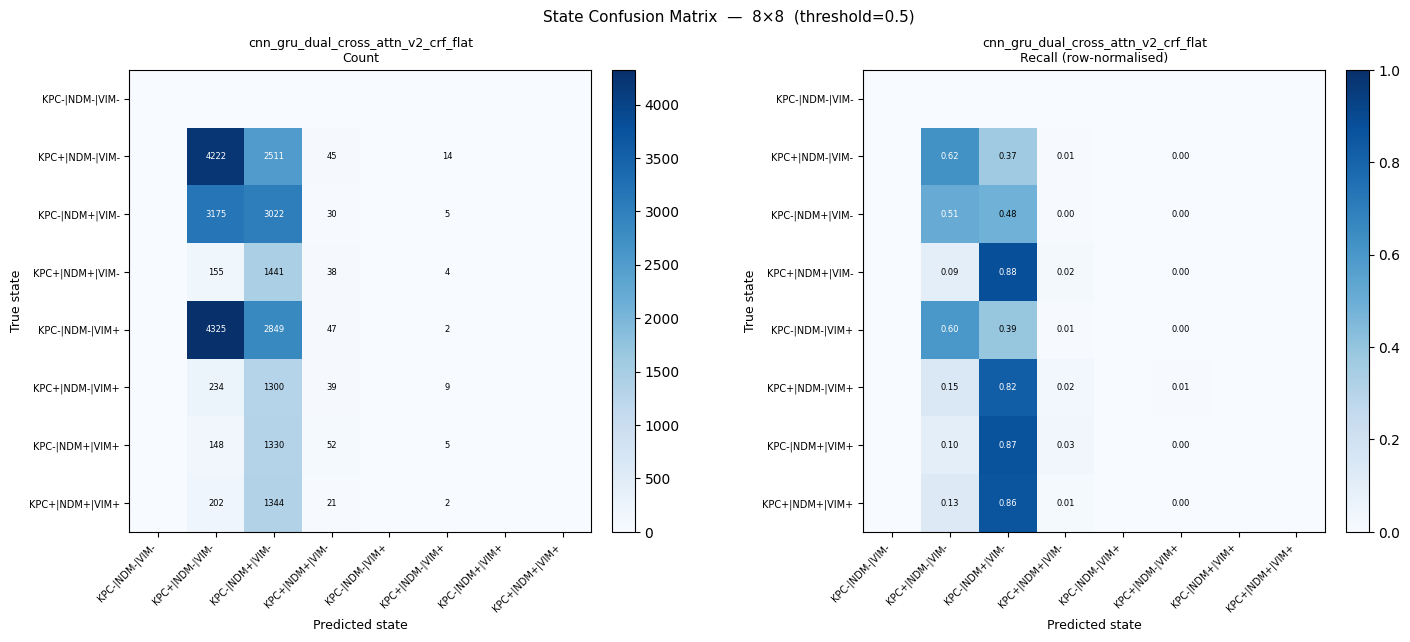


Overall accuracy: 0.274
State                                N   Correct   Recall
  KPC-|NDM-|VIM-                     0         0    0.000
  KPC+|NDM-|VIM-                  6792      4222    0.622
  KPC-|NDM+|VIM-                  6232      3022    0.485
  KPC+|NDM+|VIM-                  1638        38    0.023
  KPC-|NDM-|VIM+                  7223         0    0.000
  KPC+|NDM-|VIM+                  1582         9    0.006
  KPC-|NDM+|VIM+                  1535         0    0.000
  KPC+|NDM+|VIM+                  1569         0    0.000


In [48]:
# ── 8×8 State Confusion Matrix ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm_counts = confusion_matrix(state_idx_all, pred_state, labels=list(range(N_STATES)))

# Row-normalise → recall per true state (rows that have 0 true samples stay 0)
row_sums = cm_counts.sum(axis=1, keepdims=True)
cm_norm  = np.where(row_sums > 0, cm_counts / row_sums, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.45})

for ax, mat, title, fmt, vmax in [
    (axes[0], cm_counts, 'Count',       'd',   cm_counts.max()),
    (axes[1], cm_norm,   'Recall (row-normalised)', '.2f', 1.0),
]:
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(N_STATES))
    ax.set_xticklabels(STATE_LABELS, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels(STATE_LABELS, fontsize=7)
    ax.set_xlabel('Predicted state', fontsize=9)
    ax.set_ylabel('True state', fontsize=9)
    ax.set_title(f'{MODEL_KEY}\n{title}', fontsize=9)
    thresh = vmax * 0.5
    for r in range(N_STATES):
        for c in range(N_STATES):
            val = mat[r, c]
            if val > 0:
                txt = (f'{int(val)}' if fmt == 'd' else f'{val:{fmt}}')
                ax.text(c, r, txt, ha='center', va='center', fontsize=6,
                        color='white' if val > thresh else 'black')

plt.suptitle(f'State Confusion Matrix  —  {N_STATES}×{N_STATES}  (threshold=0.5)', fontsize=11)
plt.show()

# Per-state accuracy summary
print(f'\nOverall accuracy: {(pred_state == state_idx_all).mean():.3f}')
print(f'{"State":30s}  {"N":>6}  {"Correct":>8}  {"Recall":>7}')
for s in range(N_STATES):
    n   = (state_idx_all == s).sum()
    cor = cm_counts[s, s]
    rec = cm_norm[s, s]
    print(f'  {STATE_LABELS[s]:28s}  {n:6d}  {cor:8d}  {rec:7.3f}')


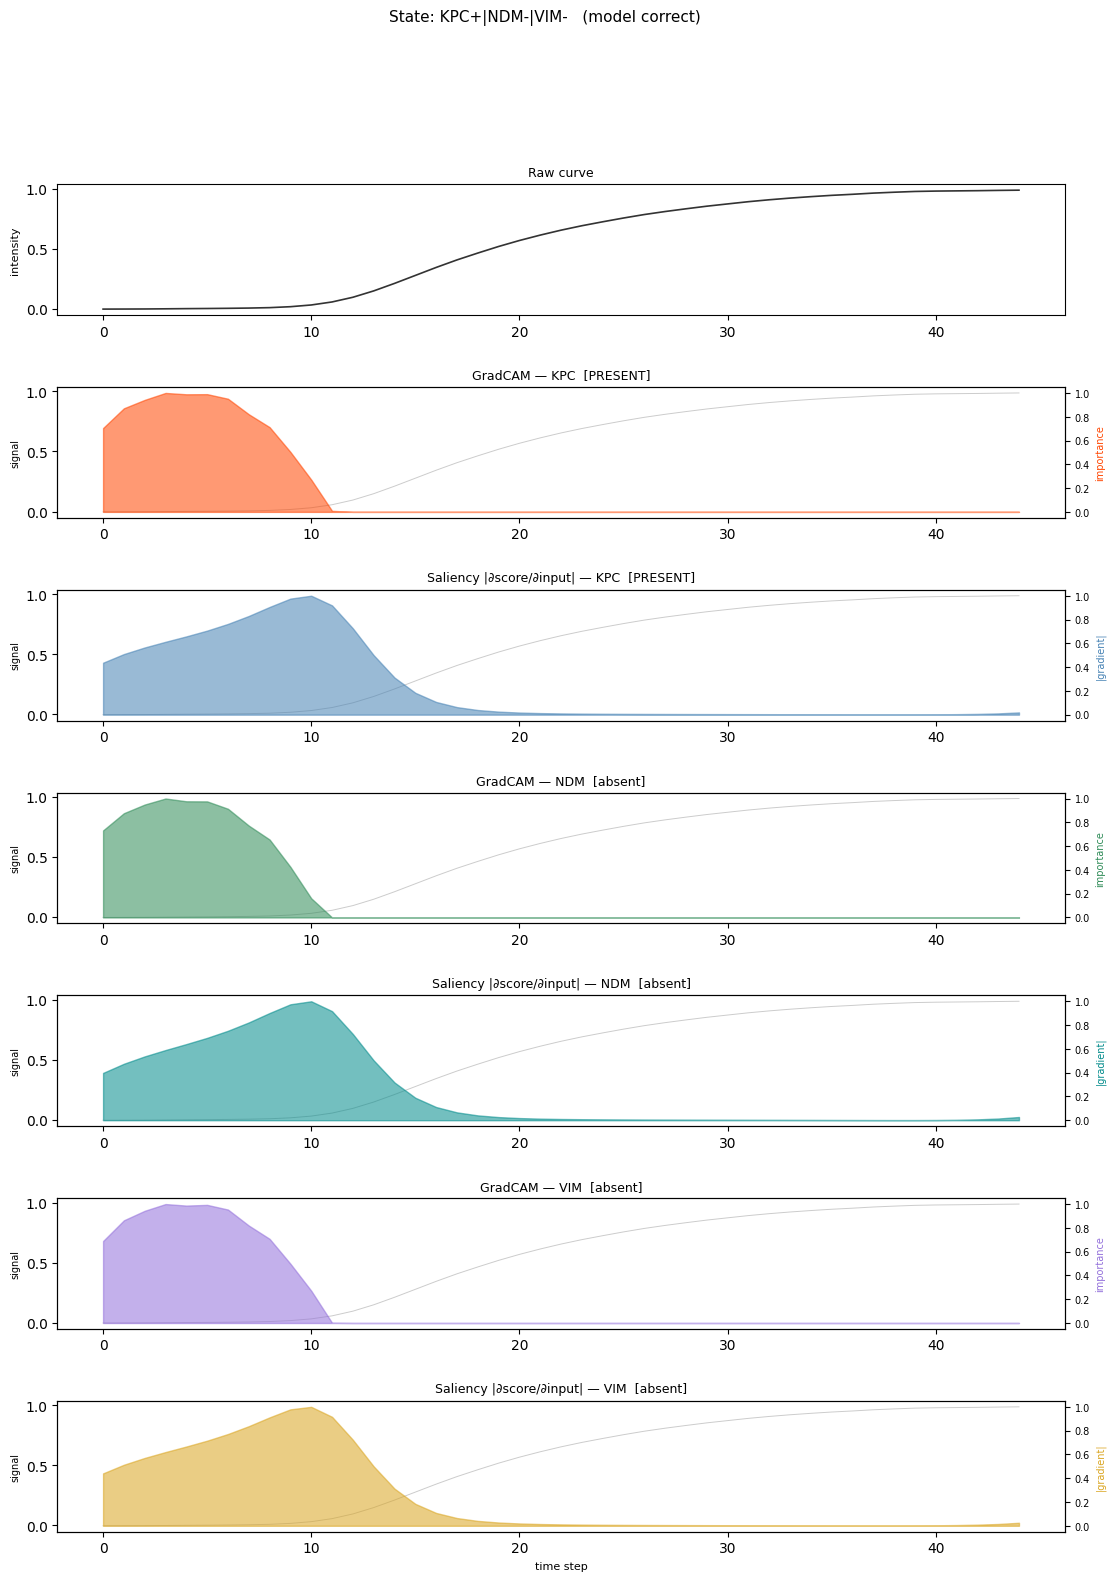

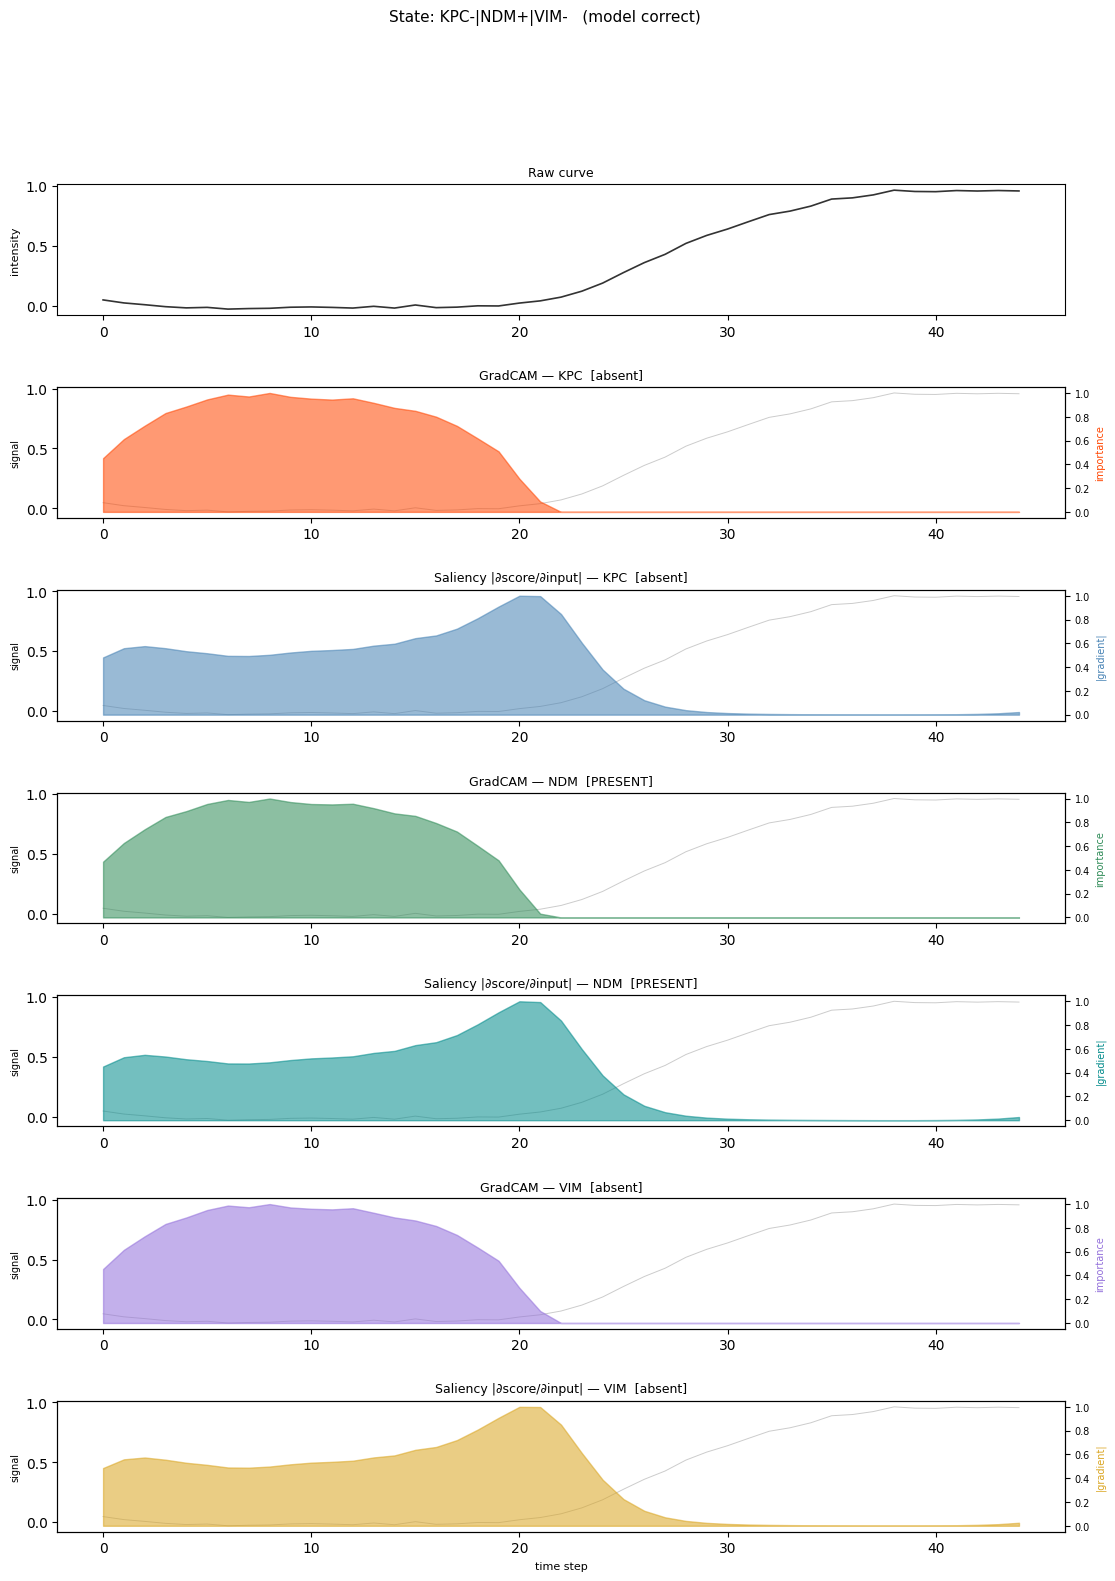

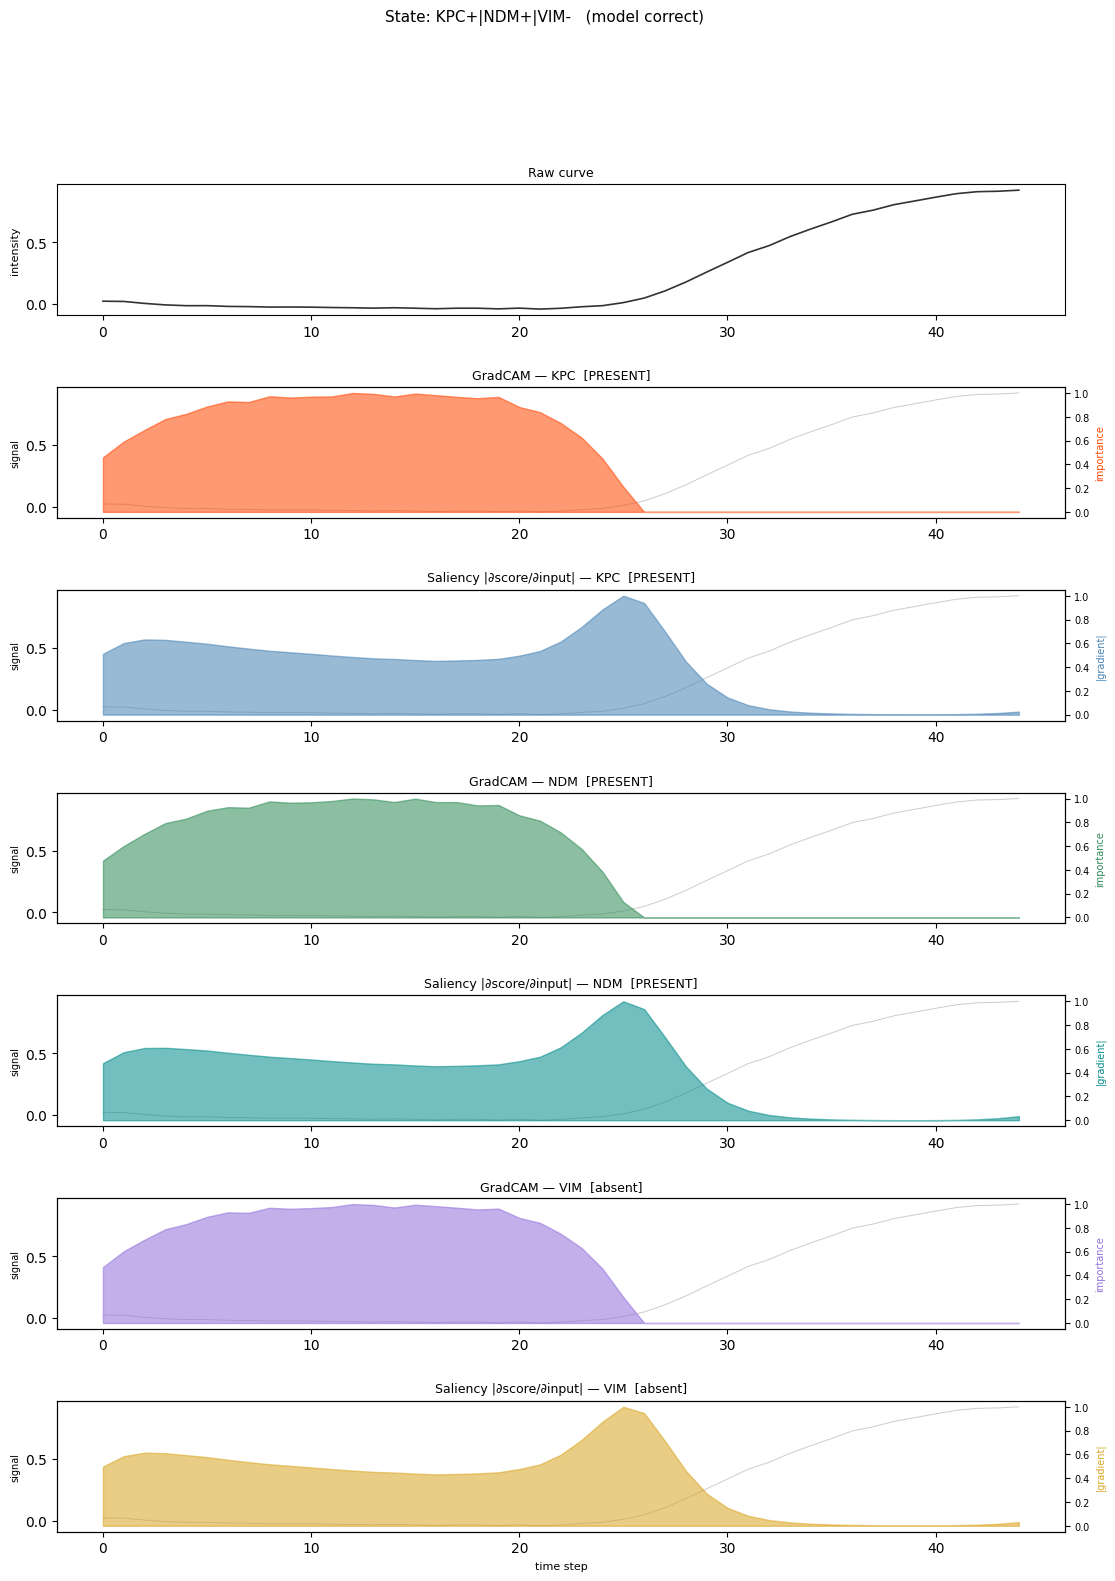

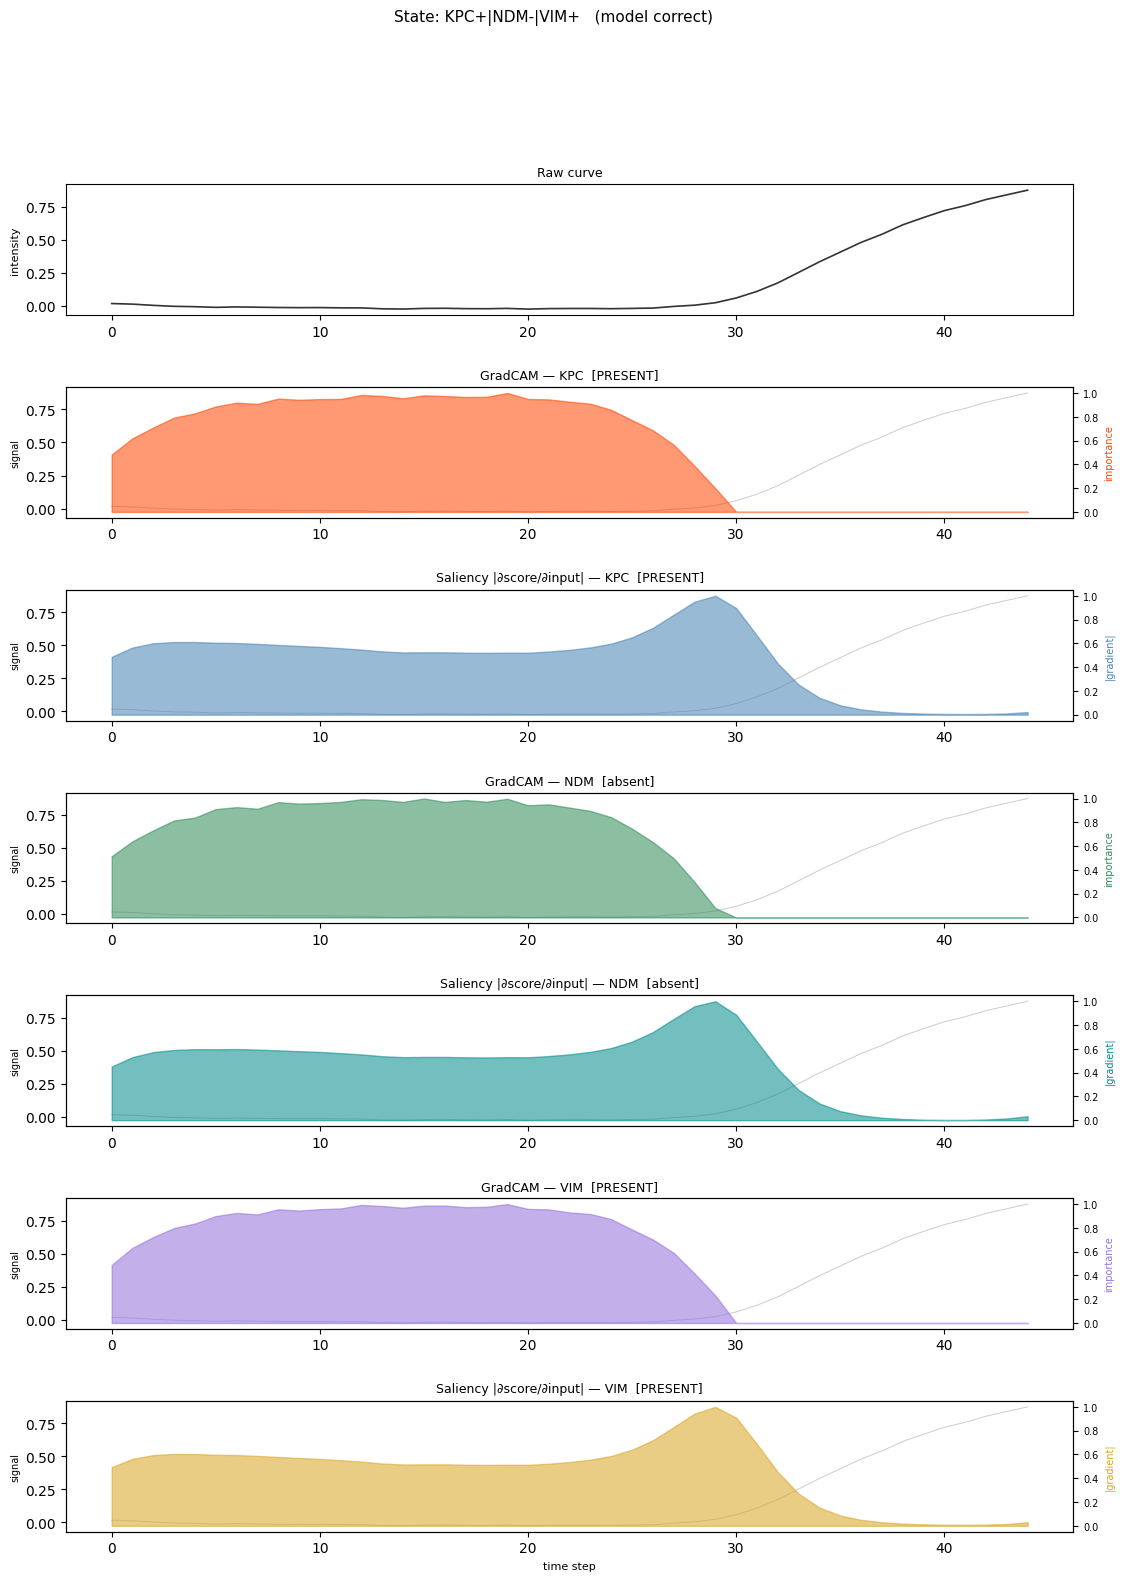

In [49]:
# ── Plot GradCAM + saliency for ALL targets on one sample ────────────────────
# Rows: raw curve, then for each target: GradCAM row + saliency row.
# Targets not present in the true state are marked (absent) — their saliency
# should be flat/low if the model has learned decoupled detectors.
COLORS_GCAM = ['orangered',    'seagreen',     'mediumpurple']
COLORS_SAL  = ['steelblue',    'darkcyan',     'goldenrod']

def _class_idx_for_label(label_j, state, is_crf):
    # For CRF the output is 8-state logits; to get a per-label gradient we use
    # the marginal: sum of state logits where bit j is set.
    # For sigmoid the output is directly per-label.
    return label_j   # for sigmoid: index directly into (B, 3)

def plot_gradcam_for_state(state, sample_idx):
    x         = X_all[sample_idx:sample_idx+1]   # (1, T, 1)
    T         = x.shape[1]
    t         = np.arange(T)
    raw_curve = x[0, :, 0]

    n_rows = 1 + 2 * N_TARGETS
    fig, axes = plt.subplots(n_rows, 1, figsize=(13, 2.5 * n_rows),
                              gridspec_kw={'hspace': 0.55})
    fig.suptitle(
        f'State: {STATE_LABELS[state]}   '
        f'({"model correct" if correct_mask[sample_idx] else "fallback — model wrong"})',
        fontsize=11)

    # Row 0: raw curve
    axes[0].plot(t, raw_curve, color='#333', lw=1.2)
    axes[0].set_title('Raw curve', fontsize=9)
    axes[0].set_ylabel('intensity', fontsize=8)

    for j, target in enumerate(TARGETS):
        present = bool((state >> j) & 1)
        tag     = f'{target}  [{"PRESENT" if present else "absent"}]'

        if IS_CRF:
            # Gradient of the sum of state logits where bit j is set
            x_var = tf.Variable(tf.cast(x, tf.float32))
            with tf.GradientTape() as tape:
                out = model(x_var, training=False)
                if isinstance(out, (list, tuple)): out = out[0]
                states_j = [s for s in range(N_STATES) if (s >> j) & 1]
                score = tf.reduce_sum(tf.gather(out[0], states_j))
            sal = tf.abs(tape.gradient(score, x_var)).numpy()[0, :, 0]

            gm = tf.keras.Model(
                inputs=model.inputs,
                outputs=[model.get_layer('ca2_kv_proj').output,
                         model.outputs[0] if isinstance(model.output, list) else model.output])
            x_t = tf.cast(x, tf.float32)
            with tf.GradientTape() as tape2:
                kv_out, preds = gm(x_t, training=False)
                tape2.watch(kv_out)
                score2 = tf.reduce_sum(tf.gather(preds[0], states_j))
            grads = tape2.gradient(score2, kv_out)
            gcam  = tf.nn.relu(tf.reduce_mean(grads * kv_out, axis=-1)).numpy()[0]
        else:
            sal  = input_saliency(model, x, j)[0, :, 0]
            gcam = gradcam_1d(model, x, j)[0]

        sal  = sal  / (sal.max()  + 1e-8)
        gcam = gcam / (gcam.max() + 1e-8)

        # GradCAM row
        row_g  = 1 + 2 * j
        ax_g   = axes[row_g]
        ax_g2  = ax_g.twinx()
        ax_g.plot(t, raw_curve, color='#aaa', lw=0.7, alpha=0.6)
        ax_g2.fill_between(t, gcam, alpha=0.55, color=COLORS_GCAM[j])
        ax_g.set_title(f'GradCAM — {tag}', fontsize=9)
        ax_g.set_ylabel('signal', fontsize=7)
        ax_g2.set_ylabel('importance', fontsize=7, color=COLORS_GCAM[j])
        ax_g2.tick_params(labelsize=7)

        # Saliency row
        row_s  = 2 + 2 * j
        ax_s   = axes[row_s]
        ax_s2  = ax_s.twinx()
        ax_s.plot(t, raw_curve, color='#aaa', lw=0.7, alpha=0.6)
        ax_s2.fill_between(t, sal, alpha=0.55, color=COLORS_SAL[j])
        ax_s.set_title(f'Saliency |∂score/∂input| — {tag}', fontsize=9)
        ax_s.set_ylabel('signal', fontsize=7)
        ax_s2.set_ylabel('|gradient|', fontsize=7, color=COLORS_SAL[j])
        ax_s2.tick_params(labelsize=7)

    axes[-1].set_xlabel('time step', fontsize=8)
    plt.show()


for s, idx in best.items():
    plot_gradcam_for_state(s, idx)


---
## 3. Embedding Space (UMAP)

Extract the fused 96-dim `z` embedding from the backbone and project to 2D.
Each point is coloured by its 3-bit target state.  
Good separation → the backbone learned a discriminative representation.

In [50]:
# ── Extract attended-query embeddings ────────────────────────────────────────
# ca2_ffn_ln_1: output of the final CA block — shape (B, n_targets, query_dim).
# Mean over the label axis → (B, query_dim) embedding per sample.
Q_LAYER = 'ca2_ffn_ln_1'
q_model = tf.keras.Model(inputs=model.inputs,
                          outputs=model.get_layer(Q_LAYER).output)

BATCH = 256
Q_all = np.concatenate([
    q_model(X_all[i:i+BATCH], training=False).numpy()
    for i in range(0, len(X_all), BATCH)
], axis=0)   # (N, n_targets, query_dim)

Z_all = Q_all.mean(axis=1)   # (N, query_dim)  — mean over label queries
print('Embedding for UMAP:', Z_all.shape)


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['curve_input']
Received: inputs=Tensor(shape=(256, 45, 1))
  warnings.warn(msg)


Embedding for UMAP: (26571, 64)


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['curve_input']
Received: inputs=Tensor(shape=(203, 45, 1))
  warnings.warn(msg)


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_1188818/1220859979.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', N_STATES)


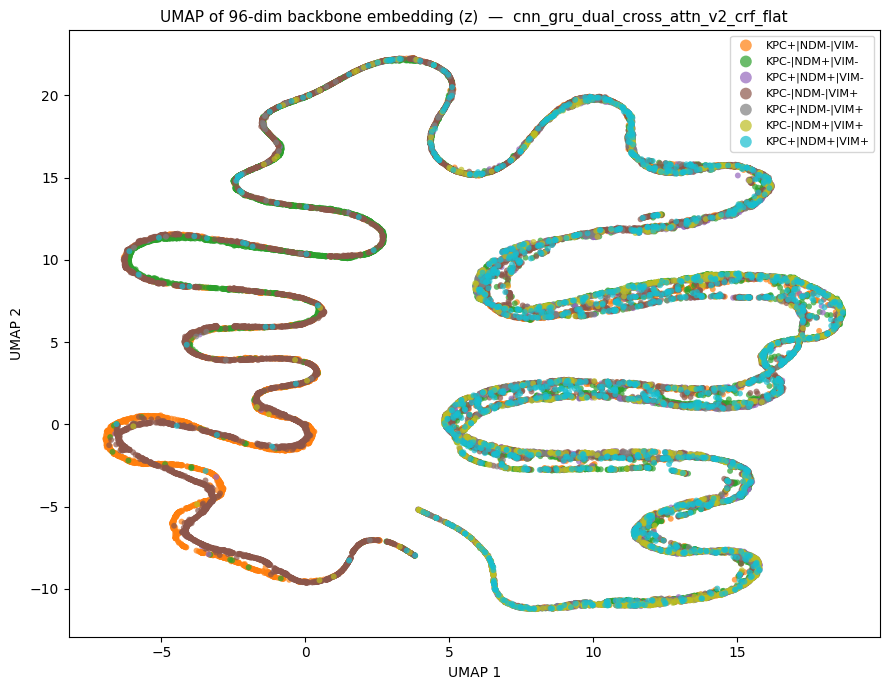

In [51]:
# ── UMAP / PCA projection ─────────────────────────────────────────────────────
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    Z_2d = reducer.fit_transform(Z_all)
    method = 'UMAP'
except ImportError:
    from sklearn.decomposition import PCA
    Z_2d = PCA(n_components=2, random_state=42).fit_transform(Z_all)
    method = 'PCA'

# Colour palette — one colour per 3-bit state
cmap = plt.cm.get_cmap('tab10', N_STATES)

fig, ax = plt.subplots(figsize=(9, 7))
for s in range(N_STATES):
    mask = state_idx_all == s
    if mask.any():
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   color=cmap(s), label=STATE_LABELS[s], s=18, alpha=0.7, edgecolors='none')

ax.legend(fontsize=8, markerscale=2, loc='best')
ax.set_title(f'{method} of 96-dim backbone embedding (z)  —  {MODEL_KEY}', fontsize=11)
ax.set_xlabel(f'{method} 1'); ax.set_ylabel(f'{method} 2')
plt.tight_layout(); plt.show()

---
## 4. CRF State Probability Heatmap

*(CRF models only.)*  
For each true state, show the average softmax distribution over all 8 states.  
A well-calibrated CRF concentrates mass on the correct state and spills into neighbouring states (those sharing 2 of 3 true labels).

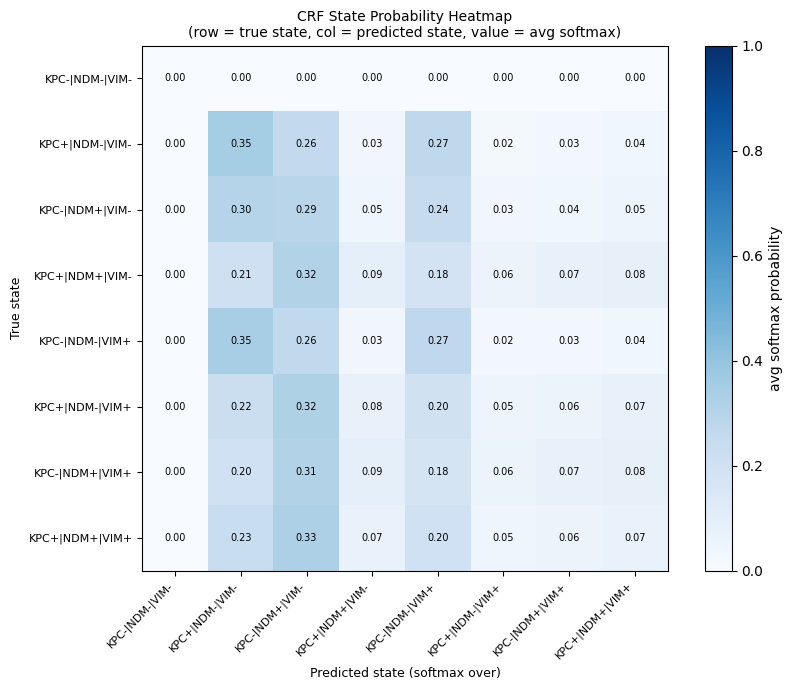

In [52]:
if not IS_CRF:
    print('Skip — not a CRF model.')
else:
    probs = tf.nn.softmax(all_logits).numpy()   # (N, 8)

    # Average softmax per true state → (8, 8) matrix
    avg_per_state = np.zeros((N_STATES, N_STATES))
    for s in range(N_STATES):
        mask = state_idx_all == s
        if mask.any():
            avg_per_state[s] = probs[mask].mean(axis=0)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(avg_per_state, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='avg softmax probability')

    ax.set_xticks(range(N_STATES)); ax.set_xticklabels(STATE_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(N_STATES)); ax.set_yticklabels(STATE_LABELS, fontsize=8)
    ax.set_xlabel('Predicted state (softmax over)', fontsize=9)
    ax.set_ylabel('True state', fontsize=9)
    ax.set_title('CRF State Probability Heatmap\n(row = true state, col = predicted state, value = avg softmax)', fontsize=10)

    for r in range(N_STATES):
        for c in range(N_STATES):
            ax.text(c, r, f'{avg_per_state[r,c]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if avg_per_state[r,c] > 0.5 else 'black')

    plt.tight_layout(); plt.show()

---
## 5. Per-Label Reliability (Calibration)

Marginal per-label probabilities vs. actual fraction of positives — binned into deciles.  
Points on the diagonal = perfectly calibrated. Points below = overconfident.

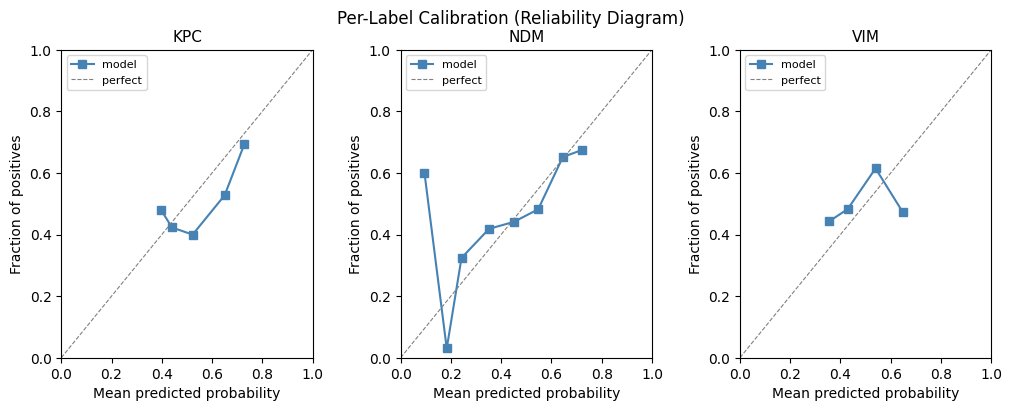

In [53]:
from sklearn.calibration import calibration_curve

if IS_CRF:
    # Marginalise state probs → per-label probs
    probs_crf = tf.nn.softmax(all_logits).numpy()   # (N, 8)
    # P(label j=1) = sum over states where bit j is set
    marginals = np.zeros((len(X_all), N_TARGETS))
    for j in range(N_TARGETS):
        states_with_j = [s for s in range(N_STATES) if (s >> j) & 1]
        marginals[:, j] = probs_crf[:, states_with_j].sum(axis=1)
else:
    marginals = tf.sigmoid(all_logits).numpy()   # (N, 3)

fig, axes = plt.subplots(1, N_TARGETS, figsize=(4 * N_TARGETS, 4),
                          gridspec_kw={'wspace': 0.35})

for j, target in enumerate(TARGETS):
    prob_true, prob_pred = calibration_curve(y_all[:, j], marginals[:, j], n_bins=10)
    axes[j].plot(prob_pred, prob_true, 's-', label='model', color='steelblue')
    axes[j].plot([0, 1], [0, 1], '--', color='grey', lw=0.8, label='perfect')
    axes[j].set_title(f'{target}', fontsize=11)
    axes[j].set_xlabel('Mean predicted probability')
    axes[j].set_ylabel('Fraction of positives')
    axes[j].set_xlim(0, 1); axes[j].set_ylim(0, 1)
    axes[j].legend(fontsize=8)

fig.suptitle('Per-Label Calibration (Reliability Diagram)', fontsize=12)
plt.show()

---
## 6. Per-Label ROC Curves

One ROC curve per label using marginalised probabilities. Good for comparing models.

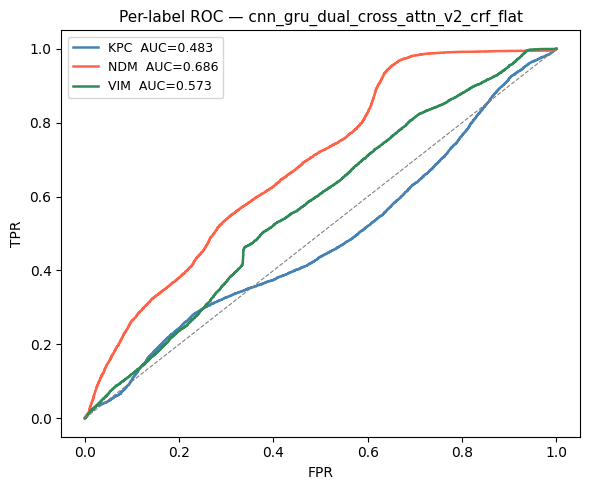

In [54]:
from sklearn.metrics import roc_auc_score

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['steelblue', 'tomato', 'seagreen']

for j, target in enumerate(TARGETS):
    fpr, tpr, _ = roc_curve(y_all[:, j], marginals[:, j])
    auc = roc_auc_score(y_all[:, j], marginals[:, j])
    ax.plot(fpr, tpr, label=f'{target}  AUC={auc:.3f}', color=colors[j], lw=1.8)

ax.plot([0, 1], [0, 1], '--', color='grey', lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'Per-label ROC — {MODEL_KEY}', fontsize=11)
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

---
## 7. Attention vs. Curve Amplitude Correlation

Scatter plot: for each label, does the model attend more to time regions with higher signal amplitude?  
If attention correlates with amplitude → the model uses local peak features.  
If not → the model uses structural/shape cues (e.g. slope, plateau).

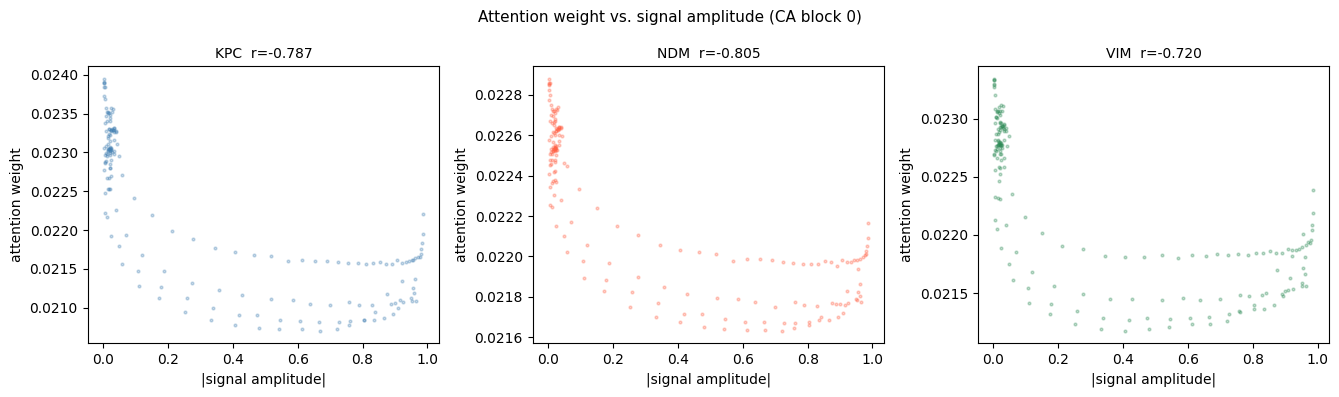

In [55]:
# Compute attention for all best samples and check amplitude correlation
best_x = np.stack([X_all[idx] for idx in best.values()])   # (n_states, T, 1)
best_s = np.array(list(best.keys()))
weights_best = get_attention_weights(best_x)

ca0_avg_best = weights_best['ca_0'].mean(axis=1)  # (n_states, n_targets, T)
amplitude    = np.abs(best_x[:, :, 0])            # (n_states, T)

fig, axes = plt.subplots(1, N_TARGETS, figsize=(4.5 * N_TARGETS, 4))
for j, target in enumerate(TARGETS):
    attn_j   = ca0_avg_best[:, j, :]   # (n_states, T)
    # Flatten: each (state, time) is one point
    amp_flat  = amplitude.ravel()
    attn_flat = attn_j.ravel()

    axes[j].scatter(amp_flat, attn_flat, s=4, alpha=0.3, color=colors[j])
    # Add correlation
    r = np.corrcoef(amp_flat, attn_flat)[0, 1]
    axes[j].set_title(f'{target}  r={r:.3f}', fontsize=10)
    axes[j].set_xlabel('|signal amplitude|')
    axes[j].set_ylabel('attention weight')

fig.suptitle('Attention weight vs. signal amplitude (CA block 0)', fontsize=11)
plt.tight_layout(); plt.show()